# Aggregate Results Plots

Use this notebook after experiments have finished. It imports `scripts.aggregate_results`, displays seed-aggregated training curves inline, and can optionally save the figures and CSV summaries.

## Setup

Run this from the repository root locally. In Colab, clone or mount the repository first, then adjust `REPO_ROOT` if your checkout lives somewhere else.

In [ ]:
%pwd

In [ ]:
REPO_ROOT

In [2]:
from pathlib import Path

REPO_ROOT = Path('/Users/dhillo/Garage/Quant/Reinforcement Learning/trpo_latest_code 2/trpo/')

In [3]:
%matplotlib inline

from pathlib import Path
import os
import sys

#REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "scripts" / "aggregate_results.py").exists():
    for candidate in [Path("/content/trpo"), Path("/content/drive/MyDrive/trpo")]:
        if (candidate / "scripts" / "aggregate_results.py").exists():
            REPO_ROOT = candidate.resolve()
            break

if not (REPO_ROOT / "scripts" / "aggregate_results.py").exists():
    raise FileNotFoundError("Set REPO_ROOT to the checkout that contains scripts/aggregate_results.py")

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Using repository: {REPO_ROOT}")

Using repository: /Users/dhillo/Garage/Quant/Reinforcement Learning/trpo_latest_code 2/trpo


In [4]:
import importlib
import scripts.aggregate_results as aggregate_results

# Reload the module so notebook kernels pick up recent edits to scripts/aggregate_results.py.
aggregate_results = importlib.reload(aggregate_results)
from scripts.aggregate_results import discover_run_groups, plot_aggregate_results

## Plot Options

Set `SAVE_FIGURES = True` to write report-ready figures. PDF is the default here because it stays sharp in modern LaTeX and preserves transparency better than EPS.

In [5]:
OUTPUTS_ROOT = REPO_ROOT / "outputs"

METRIC = "train_return_mean"
X_AXIS = "epoch"
SMOOTH_WINDOW = 1
INTERVAL = "std"  # choices: "std", "sem", "ci95", "none"

SAVE_FIGURES = True
SAVE_FORMATS = ["pdf"]  # Use ["png", "pdf"] if you also want quick preview images.
SAVE_DIR = REPO_ROOT / "report" / "figures"

## Available Runs

In [7]:
catalog = discover_run_groups(OUTPUTS_ROOT)
display(catalog[["run_name", "env_id", "suite", "method", "method_variant", "num_seeds", "completed_epochs"]])

,run_name,env_id,suite,method,method_variant,num_seeds,completed_epochs
0,beamrider_ppo_clip,ALE/BeamRider-v5,atari,ppo,clip,1,300.0
1,beamrider_single_path,ALE/BeamRider-v5,atari,trpo,trpo_paper,1,300.0
2,enduro_ppo_clip,ALE/Enduro-v5,atari,ppo,clip,1,300.0
3,enduro_single_path,ALE/Enduro-v5,atari,trpo,trpo_paper,1,300.0
4,hopper_natural_pg,Hopper-v5,mujoco,natural_pg,trpo_paper,3,200.0
5,hopper_natural_pg_3x,Hopper-v5,mujoco,natural_pg,trpo_paper,3,200.0
6,hopper_natural_pg_9x,Hopper-v5,mujoco,natural_pg,trpo_paper,3,200.0
7,hopper_ppo_clip,Hopper-v5,mujoco,ppo,clip,3,200.0
8,hopper_single_path,Hopper-v5,mujoco,trpo,trpo_paper,3,200.0
9,pong_ppo_clip,ALE/Pong-v5,atari,ppo,clip,1,300.0


In [8]:
def existing_entries(entries):
    roots = []
    labels = []
    missing = []
    for rel_path, label in entries:
        root = REPO_ROOT / rel_path
        if root.exists():
            roots.append(root)
            labels.append(label)
        else:
            missing.append(str(rel_path))
    if missing:
        print("Skipping missing run roots:", ", ".join(missing))
    return roots, labels


def plot_many(comparisons, section_name, title_suffix):
    results = {}
    for env_id, entries in comparisons.items():
        roots, labels = existing_entries(entries)
        if not roots:
            print(f"No runs found for {env_id}; skipping.")
            continue
        result = plot_aggregate_results(
            roots,
            labels=labels,
            metric=METRIC,
            x_axis=X_AXIS,
            title=f"{env_id}: {title_suffix}",
            smooth_window=SMOOTH_WINDOW,
            interval=INTERVAL,
            save=SAVE_FIGURES,
            save_formats=SAVE_FORMATS,
            output_dir=SAVE_DIR / section_name,
            save_summary=True,
            show=True,
        )
        results[env_id] = result
        display(result.summary)
    return results

## Locomotion: TRPO vs NPG vs PPO

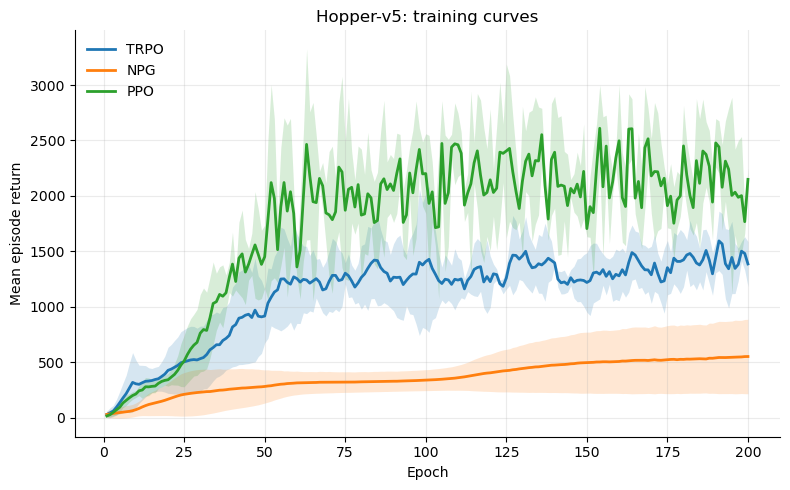

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,Hopper-v5,train_return_mean,epoch,200.0,1386.729149,202.586730,191.0,1594.577250,267.736054,3
1,NPG,Hopper-v5,train_return_mean,epoch,200.0,552.258788,335.514444,200.0,552.258788,335.514444,3
2,PPO,Hopper-v5,train_return_mean,epoch,200.0,2149.465920,102.696360,154.0,2609.998041,389.565562,3


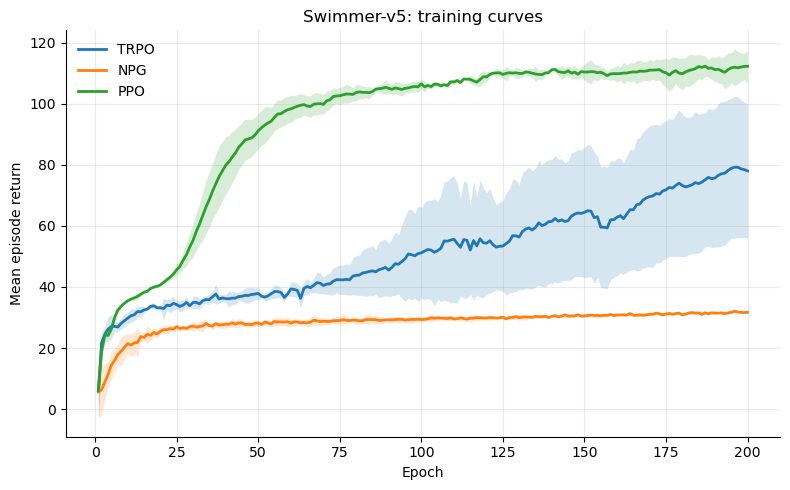

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,Swimmer-v5,train_return_mean,epoch,200.0,77.994631,21.967962,196.0,79.216283,23.293852,3
1,NPG,Swimmer-v5,train_return_mean,epoch,200.0,31.693161,0.261810,196.0,32.034166,0.394783,3
2,PPO,Swimmer-v5,train_return_mean,epoch,200.0,112.279961,5.320605,187.0,112.308127,3.377352,3


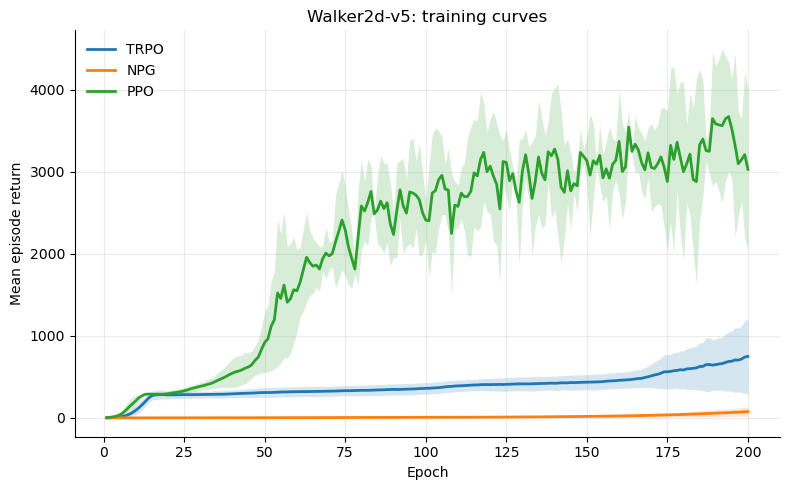

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,Walker2d-v5,train_return_mean,epoch,200.0,746.705229,458.971975,200.0,746.705229,458.971975,3
1,NPG,Walker2d-v5,train_return_mean,epoch,200.0,73.309770,56.412896,200.0,73.309770,56.412896,3
2,PPO,Walker2d-v5,train_return_mean,epoch,200.0,3027.238862,985.822404,194.0,3670.919302,667.612340,3


In [9]:
LOCOMOTION_COMPARISONS = {
    "Hopper-v5": [
        (Path("outputs/hopper_single_path"), "TRPO"),
        (Path("outputs/hopper_natural_pg"), "NPG"),
        (Path("outputs/hopper_ppo_clip"), "PPO"),
    ],
    "Swimmer-v5": [
        (Path("outputs/swimmer_single_path"), "TRPO"),
        (Path("outputs/swimmer_natural_pg"), "NPG"),
        (Path("outputs/swimmer_ppo_clip"), "PPO"),
    ],
    "Walker2d-v5": [
        (Path("outputs/walker2d_single_path"), "TRPO"),
        (Path("outputs/walker2d_natural_pg"), "NPG"),
        (Path("outputs/walker2d_ppo_clip"), "PPO"),
    ],
}

locomotion_results = plot_many(LOCOMOTION_COMPARISONS, "locomotion", "training curves")

## NPG Step-Size Ablation

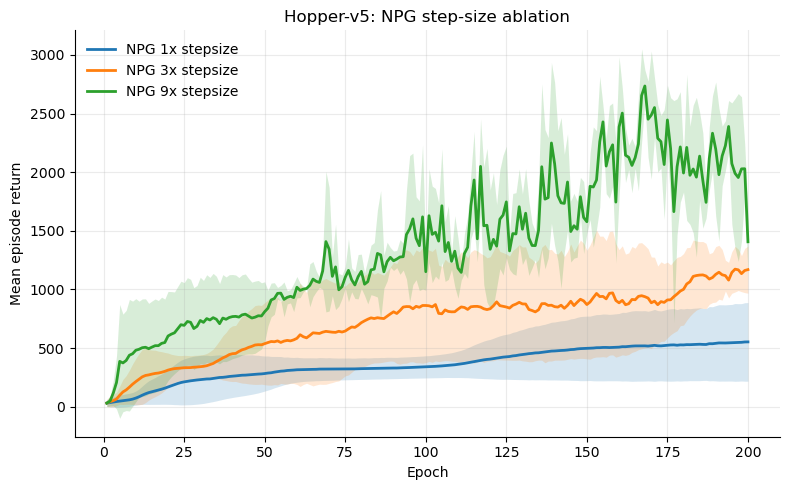

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,NPG 1x stepsize,Hopper-v5,train_return_mean,epoch,200.0,552.258788,335.514444,200.0,552.258788,335.514444,3
1,NPG 3x stepsize,Hopper-v5,train_return_mean,epoch,200.0,1168.959140,201.110908,196.0,1172.833375,194.819776,3
2,NPG 9x stepsize,Hopper-v5,train_return_mean,epoch,200.0,1406.271540,264.418861,168.0,2735.634618,138.002647,3


In [10]:
NPG_ABLATIONS = {
    "Hopper-v5": [
        (Path("outputs/hopper_natural_pg"), "NPG 1x stepsize"),
        (Path("outputs/hopper_natural_pg_3x"), "NPG 3x stepsize"),
        (Path("outputs/hopper_natural_pg_9x"), "NPG 9x stepsize"),
    ],
}

npg_ablation_results = plot_many(NPG_ABLATIONS, "npg_ablation", "NPG step-size ablation")

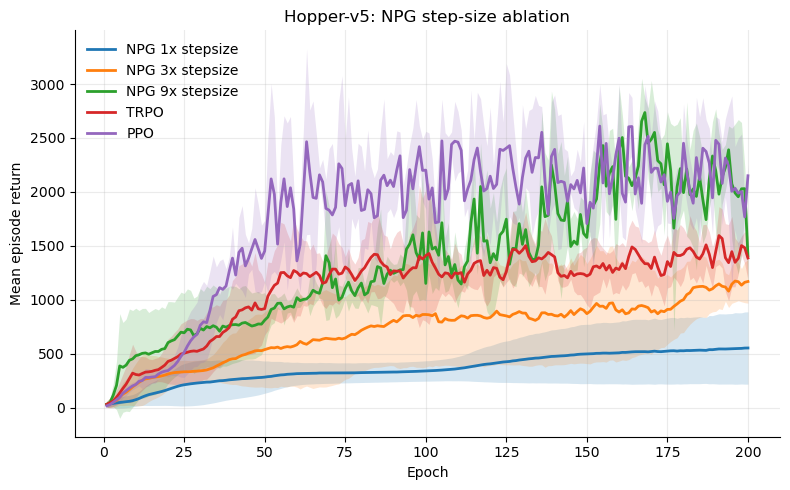

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,NPG 1x stepsize,Hopper-v5,train_return_mean,epoch,200.0,552.258788,335.514444,200.0,552.258788,335.514444,3
1,NPG 3x stepsize,Hopper-v5,train_return_mean,epoch,200.0,1168.959140,201.110908,196.0,1172.833375,194.819776,3
2,NPG 9x stepsize,Hopper-v5,train_return_mean,epoch,200.0,1406.271540,264.418861,168.0,2735.634618,138.002647,3
3,TRPO,Hopper-v5,train_return_mean,epoch,200.0,1386.729149,202.586730,191.0,1594.577250,267.736054,3
4,PPO,Hopper-v5,train_return_mean,epoch,200.0,2149.465920,102.696360,154.0,2609.998041,389.565562,3


In [11]:
NPG_ABLATIONS = {
    "Hopper-v5": [
        (Path("outputs/hopper_natural_pg"), "NPG 1x stepsize"),
        (Path("outputs/hopper_natural_pg_3x"), "NPG 3x stepsize"),
        (Path("outputs/hopper_natural_pg_9x"), "NPG 9x stepsize"),
        (Path("outputs/hopper_single_path"), "TRPO"),
        (Path("outputs/hopper_ppo_clip"), "PPO"),
    ],
}

npg_ablation_results = plot_many(NPG_ABLATIONS, "npg_ablation", "NPG step-size ablation")

## Atari Comparisons

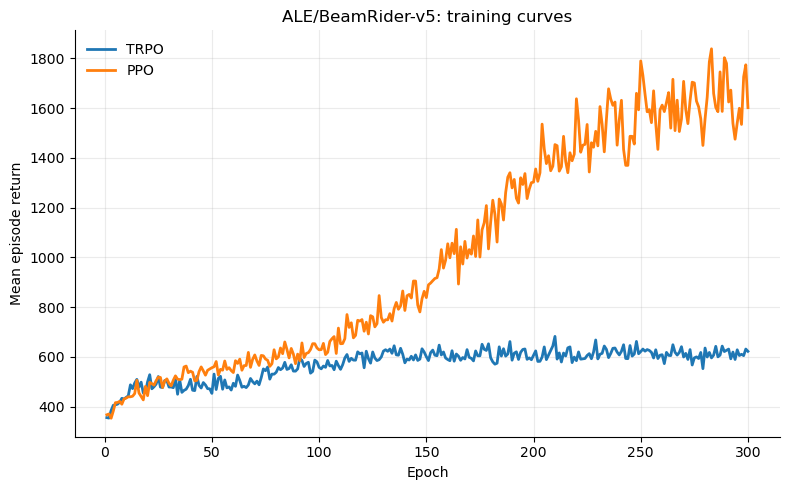

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,ALE/BeamRider-v5,train_return_mean,epoch,300.0,622.140845,NaN,210.0,682.222222,NaN,1
1,PPO,ALE/BeamRider-v5,train_return_mean,epoch,300.0,1601.707317,NaN,283.0,1838.444444,NaN,1


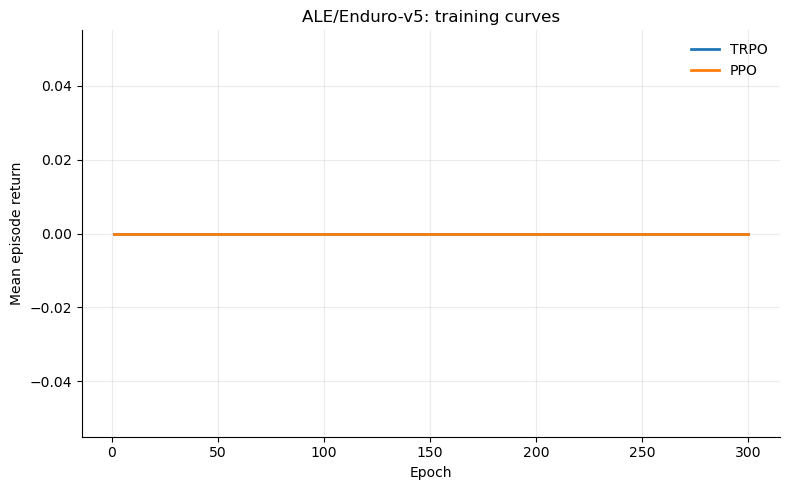

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,ALE/Enduro-v5,train_return_mean,epoch,300.0,0.0,NaN,1.0,0.0,NaN,1
1,PPO,ALE/Enduro-v5,train_return_mean,epoch,300.0,0.0,NaN,1.0,0.0,NaN,1


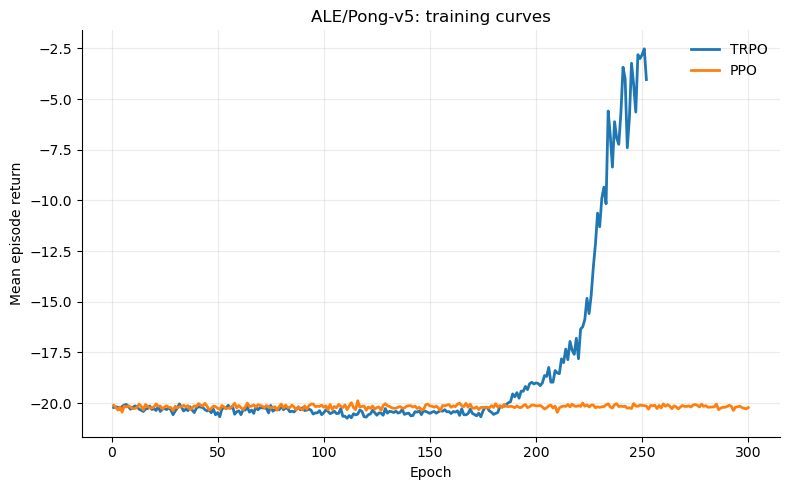

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,ALE/Pong-v5,train_return_mean,epoch,252.0,-4.038462,NaN,251.0,-2.520000,NaN,1
1,PPO,ALE/Pong-v5,train_return_mean,epoch,300.0,-20.219048,NaN,116.0,-19.882353,NaN,1


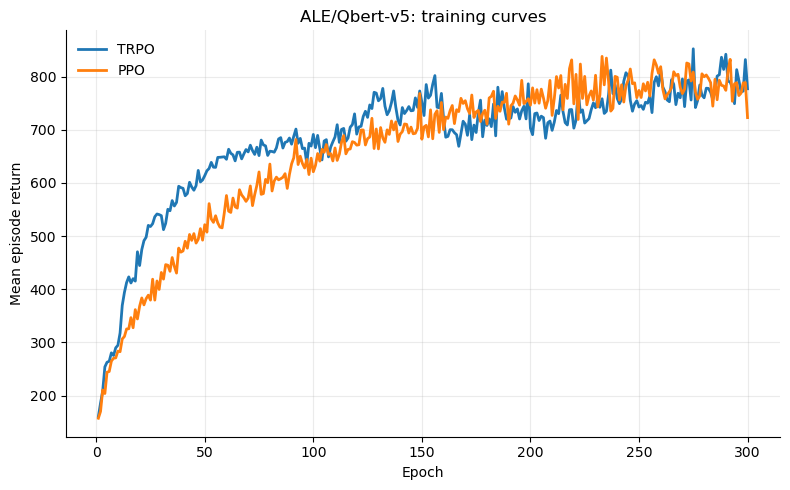

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,ALE/Qbert-v5,train_return_mean,epoch,300.0,776.963351,NaN,275.0,852.168367,NaN,1
1,PPO,ALE/Qbert-v5,train_return_mean,epoch,300.0,722.781065,NaN,233.0,837.878788,NaN,1


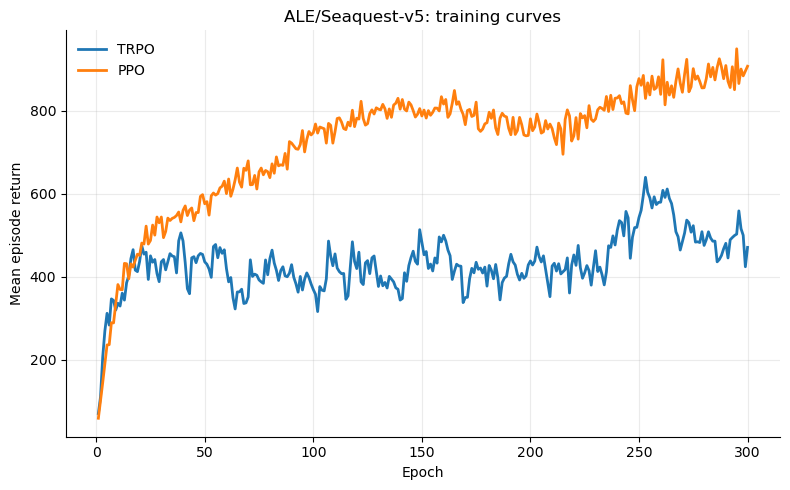

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,ALE/Seaquest-v5,train_return_mean,epoch,300.0,471.081081,NaN,253.0,640.000000,NaN,1
1,PPO,ALE/Seaquest-v5,train_return_mean,epoch,300.0,907.741935,NaN,295.0,949.830508,NaN,1


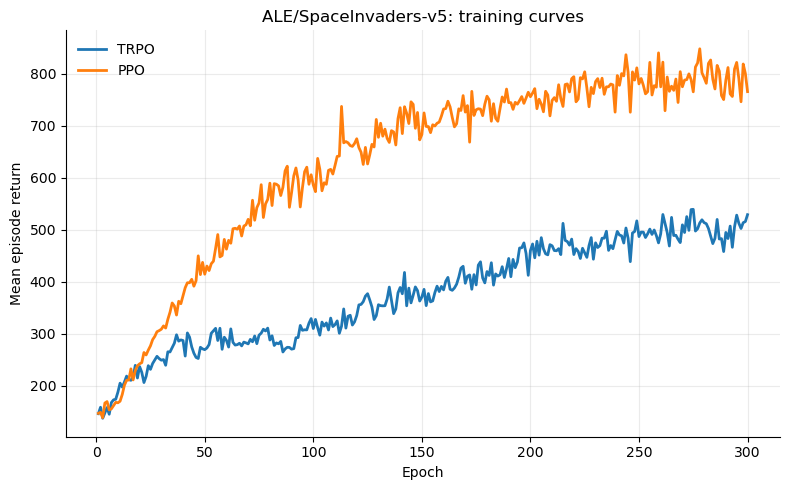

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,ALE/SpaceInvaders-v5,train_return_mean,epoch,300.0,528.945312,NaN,275.0,539.212598,NaN,1
1,PPO,ALE/SpaceInvaders-v5,train_return_mean,epoch,300.0,765.617284,NaN,278.0,848.000000,NaN,1


In [12]:
ATARI_COMPARISONS = {
    "ALE/BeamRider-v5": [
        (Path("outputs/beamrider_single_path"), "TRPO"),
        (Path("outputs/beamrider_ppo_clip"), "PPO"),
    ],
    "ALE/Enduro-v5": [
        (Path("outputs/enduro_single_path"), "TRPO"),
        (Path("outputs/enduro_ppo_clip"), "PPO"),
    ],
    "ALE/Pong-v5": [
        (Path("outputs/pong_single_path"), "TRPO"),
        (Path("outputs/pong_ppo_clip"), "PPO"),
    ],
    "ALE/Qbert-v5": [
        (Path("outputs/qbert_single_path"), "TRPO"),
        (Path("outputs/qbert_ppo_clip"), "PPO"),
    ],
    "ALE/Seaquest-v5": [
        (Path("outputs/seaquest_single_path"), "TRPO"),
        (Path("outputs/seaquest_ppo_clip"), "PPO"),
    ],
    "ALE/SpaceInvaders-v5": [
        (Path("outputs/spaceinvaders_single_path"), "TRPO"),
        (Path("outputs/spaceinvaders_ppo_clip"), "PPO"),
    ],
}

atari_results = plot_many(ATARI_COMPARISONS, "atari", "training curves")

## Custom Comparison

In [13]:
CUSTOM_RUNS = [
    # (Path("outputs/my_trpo_run"), "TRPO"),
    # (Path("outputs/my_ppo_run"), "PPO"),
]

if CUSTOM_RUNS:
    roots, labels = existing_entries(CUSTOM_RUNS)
    custom_result = plot_aggregate_results(
        roots,
        labels=labels,
        metric=METRIC,
        x_axis=X_AXIS,
        title="Custom comparison",
        smooth_window=SMOOTH_WINDOW,
        interval=INTERVAL,
        save=SAVE_FIGURES,
        save_formats=SAVE_FORMATS,
        output_dir=SAVE_DIR / "custom",
        save_summary=True,
        show=True,
    )
    display(custom_result.summary)

## Sanity-Check Tables and Run Logistics

These cells regenerate report-style tables directly from the output folders. They are meant for audit work: final/best returns, KL diagnostics, ablation volatility, hyperparameters, runtime/CUDA details, and analytic model parameter counts.

In [14]:
from scripts.aggregate_results import (
    collect_run_hyperparameters,
    collect_seed_run_details,
    make_atari_report_table,
    make_locomotion_report_table,
    make_npg_ablation_table,
    summarize_run_groups,
)


def dedupe_entries(*comparison_dicts):
    entries = []
    seen = set()
    for comparison in comparison_dicts:
        for group_entries in comparison.values():
            for path, label in group_entries:
                key = (str(path), label)
                if key not in seen:
                    seen.add(key)
                    entries.append((path, label))
    return entries


REPORT_RUN_GROUPS = dedupe_entries(LOCOMOTION_COMPARISONS, ATARI_COMPARISONS)
NPG_STEP_ABLATION_RUNS = [
    (Path("outputs/hopper_natural_pg"), "NPG 1x stepsize"),
    (Path("outputs/hopper_natural_pg_3x"), "NPG 3x stepsize"),
    (Path("outputs/hopper_natural_pg_9x"), "NPG 9x stepsize"),
]

In [15]:
locomotion_report_table = make_locomotion_report_table(
    REPORT_RUN_GROUPS,
    metric=METRIC,
    x_axis=X_AXIS,
)
display(locomotion_report_table)

print(locomotion_report_table.to_latex(index=False, float_format=lambda x: f"{x:.5g}"))

,environment,method,num_seeds,final_return,final_return_mean,final_return_std,best_return,mean_kl,min_kl,max_kl,kl_gt_threshold_pct,mean_abs_return_delta
0,Hopper-v5,TRPO,3,1386.7 +/- 165.4,1386.729149,165.411372,2186.729365,0.009158,0.006278,0.009997,0.000000,65.642626
1,Hopper-v5,NPG,3,552.3 +/- 273.9,552.258788,273.946396,939.632792,0.000201,0.000023,0.001368,0.000000,3.235176
2,Hopper-v5,PPO,3,2149.5 +/- 83.9,2149.465920,83.851227,3201.123734,0.014960,0.004365,0.024305,87.500000,294.253823
3,Swimmer-v5,TRPO,3,78.0 +/- 17.9,77.994631,17.936766,97.832074,0.007048,0.003560,0.009873,0.000000,1.078880
4,Swimmer-v5,NPG,3,31.7 +/- 0.2,31.693161,0.213767,32.312226,0.000020,0.000002,0.000420,0.000000,0.475893
5,Swimmer-v5,PPO,3,112.3 +/- 4.3,112.279961,4.344256,116.844017,0.008265,0.000927,0.019969,35.000000,0.947251
6,Walker2d-v5,TRPO,3,746.7 +/- 374.7,746.705229,374.749048,1270.605558,0.009056,0.006376,0.009946,0.000000,4.652917
7,Walker2d-v5,NPG,3,73.3 +/- 46.1,73.309770,46.060936,109.252215,0.000016,0.000003,0.000068,0.000000,0.389086
8,Walker2d-v5,PPO,3,3027.2 +/- 804.9,3027.238862,804.920622,4599.485112,0.013958,0.006754,0.023993,79.666667,196.419924


\begin{tabular}{llrlrrrrrrrr}
\toprule
environment & method & num_seeds & final_return & final_return_mean & final_return_std & best_return & mean_kl & min_kl & max_kl & kl_gt_threshold_pct & mean_abs_return_delta \\
\midrule
Hopper-v5 & TRPO & 3 & 1386.7 +/- 165.4 & 1386.7 & 165.41 & 2186.7 & 0.0091575 & 0.0062781 & 0.0099971 & 0 & 65.643 \\
Hopper-v5 & NPG & 3 & 552.3 +/- 273.9 & 552.26 & 273.95 & 939.63 & 0.00020077 & 2.2899e-05 & 0.0013681 & 0 & 3.2352 \\
Hopper-v5 & PPO & 3 & 2149.5 +/- 83.9 & 2149.5 & 83.851 & 3201.1 & 0.01496 & 0.0043651 & 0.024305 & 87.5 & 294.25 \\
Swimmer-v5 & TRPO & 3 & 78.0 +/- 17.9 & 77.995 & 17.937 & 97.832 & 0.0070482 & 0.0035596 & 0.009873 & 0 & 1.0789 \\
Swimmer-v5 & NPG & 3 & 31.7 +/- 0.2 & 31.693 & 0.21377 & 32.312 & 2.013e-05 & 1.5776e-06 & 0.00041976 & 0 & 0.47589 \\
Swimmer-v5 & PPO & 3 & 112.3 +/- 4.3 & 112.28 & 4.3443 & 116.84 & 0.0082647 & 0.00092689 & 0.019969 & 35 & 0.94725 \\
Walker2d-v5 & TRPO & 3 & 746.7 +/- 374.7 & 746.71 & 374.75 & 1270.

In [16]:
atari_report_table = make_atari_report_table(
    REPORT_RUN_GROUPS,
    metric=METRIC,
    x_axis=X_AXIS,
    methods=("TRPO", "PPO"),
)
display(atari_report_table)

print(atari_report_table.to_latex(index=False, float_format=lambda x: f"{x:.5g}"))

,game,env_id,TRPO final,TRPO best,TRPO mean_kl,TRPO epochs,PPO final,PPO best,PPO mean_kl,PPO epochs
0,BeamRider,ALE/BeamRider-v5,622.140845,682.222222,0.005090,300,1601.707317,1838.444444,0.000429,300
1,Enduro,ALE/Enduro-v5,0.000000,0.000000,0.000003,300,0.000000,0.000000,0.000295,300
2,Pong,ALE/Pong-v5,-4.038462,-2.520000,0.006869,252,-20.219048,-19.882353,0.000200,300
3,Qbert,ALE/Qbert-v5,776.963351,852.168367,0.008371,300,722.781065,837.878788,0.000369,300
4,Seaquest,ALE/Seaquest-v5,471.081081,640.000000,0.007656,300,907.741935,949.830508,0.000445,300
5,SpaceInvaders,ALE/SpaceInvaders-v5,528.945312,539.212598,0.006183,300,765.617284,848.000000,0.000417,300


\begin{tabular}{llrrrrrrrr}
\toprule
game & env_id & TRPO final & TRPO best & TRPO mean_kl & TRPO epochs & PPO final & PPO best & PPO mean_kl & PPO epochs \\
\midrule
BeamRider & ALE/BeamRider-v5 & 622.14 & 682.22 & 0.00509 & 300 & 1601.7 & 1838.4 & 0.00042895 & 300 \\
Enduro & ALE/Enduro-v5 & 0 & 0 & 2.8543e-06 & 300 & 0 & 0 & 0.00029476 & 300 \\
Pong & ALE/Pong-v5 & -4.0385 & -2.52 & 0.0068687 & 252 & -20.219 & -19.882 & 0.00020028 & 300 \\
Qbert & ALE/Qbert-v5 & 776.96 & 852.17 & 0.0083714 & 300 & 722.78 & 837.88 & 0.00036879 & 300 \\
Seaquest & ALE/Seaquest-v5 & 471.08 & 640 & 0.0076559 & 300 & 907.74 & 949.83 & 0.00044493 & 300 \\
SpaceInvaders & ALE/SpaceInvaders-v5 & 528.95 & 539.21 & 0.0061825 & 300 & 765.62 & 848 & 0.00041742 & 300 \\
\bottomrule
\end{tabular}



In [17]:
npg_ablation_table = make_npg_ablation_table(
    NPG_STEP_ABLATION_RUNS,
    metric=METRIC,
    x_axis=X_AXIS,
)
display(npg_ablation_table)

print(npg_ablation_table.to_latex(index=False, float_format=lambda x: f"{x:.5g}"))

,step,label,npg_stepsize,num_seeds,final_return,final_return_mean,final_return_std,best_return,mean_kl,max_kl,kl_gt_threshold_pct,mean_abs_return_delta,max_abs_return_delta
0,1x,NPG 1x stepsize,0.015,3,552.3 +/- 273.9,552.258788,273.946396,939.632792,0.000201,0.001368,0.000000,3.235176,35.499696
1,3x,NPG 3x stepsize,0.045,3,1169.0 +/- 164.2,1168.959140,164.206369,1362.727344,0.002957,0.011938,0.666667,21.700136,205.994354
2,9x,NPG 9x stepsize,0.135,3,1406.3 +/- 215.9,1406.271540,215.897096,3053.620690,0.036402,0.156015,79.833333,192.051964,1420.648079


\begin{tabular}{llrrlrrrrrrrr}
\toprule
step & label & npg_stepsize & num_seeds & final_return & final_return_mean & final_return_std & best_return & mean_kl & max_kl & kl_gt_threshold_pct & mean_abs_return_delta & max_abs_return_delta \\
\midrule
1x & NPG 1x stepsize & 0.015 & 3 & 552.3 +/- 273.9 & 552.26 & 273.95 & 939.63 & 0.00020077 & 0.0013681 & 0 & 3.2352 & 35.5 \\
3x & NPG 3x stepsize & 0.045 & 3 & 1169.0 +/- 164.2 & 1169 & 164.21 & 1362.7 & 0.0029574 & 0.011938 & 0.66667 & 21.7 & 205.99 \\
9x & NPG 9x stepsize & 0.135 & 3 & 1406.3 +/- 215.9 & 1406.3 & 215.9 & 3053.6 & 0.036402 & 0.15601 & 79.833 & 192.05 & 1420.6 \\
\bottomrule
\end{tabular}



In [18]:
all_report_runs = dedupe_entries(LOCOMOTION_COMPARISONS, ATARI_COMPARISONS, {"npg": NPG_STEP_ABLATION_RUNS})
run_hparams = collect_run_hyperparameters(
    all_report_runs,
    metric=METRIC,
    x_axis=X_AXIS,
)

summary_columns = [
    "run_name",
    "label",
    "env_id",
    "num_seeds",
    "target_epochs",
    "completed_epochs_min",
    "completed_epochs_max",
    "steps_per_epoch",
    "gamma",
    "lam",
    "max_kl_config",
    "npg_stepsize",
    "ppo_clip_ratio",
    "ppo_pi_lr",
    "ppo_vf_lr",
    "ppo_entropy_coef",
    "policy_param_count",
    "value_param_count",
    "total_param_count",
    "cuda_device_name",
]
display(run_hparams[[column for column in summary_columns if column in run_hparams.columns]])

,run_name,label,env_id,num_seeds,target_epochs,completed_epochs_min,completed_epochs_max,steps_per_epoch,gamma,lam,max_kl_config,npg_stepsize,ppo_clip_ratio,ppo_pi_lr,ppo_vf_lr,ppo_entropy_coef,policy_param_count,value_param_count,total_param_count,cuda_device_name
0,hopper_single_path,TRPO,Hopper-v5,3,200,200,200,1000000,0.99,1.00,0.01,0.050,0.2,0.00030,0.00100,0.00,756.0,NaN,756.0,NVIDIA L4
1,hopper_natural_pg,NPG,Hopper-v5,3,200,200,200,1000000,0.99,1.00,0.01,0.015,0.2,0.00030,0.00100,0.00,756.0,NaN,756.0,NVIDIA L4
2,hopper_ppo_clip,PPO,Hopper-v5,3,200,200,200,100000,0.99,0.95,0.01,0.050,0.2,0.00030,0.00100,0.00,5126.0,4993.0,10119.0,NVIDIA L4
3,swimmer_single_path,TRPO,Swimmer-v5,3,200,200,200,100000,0.99,1.00,0.01,0.050,0.2,0.00030,0.00100,0.00,334.0,NaN,334.0,NVIDIA L4
4,swimmer_natural_pg,NPG,Swimmer-v5,3,200,200,200,100000,0.99,1.00,0.01,0.050,0.2,0.00030,0.00100,0.00,334.0,NaN,334.0,NVIDIA L4
5,swimmer_ppo_clip,PPO,Swimmer-v5,3,200,200,200,100000,0.99,0.95,0.01,0.050,0.2,0.00030,0.00100,0.00,334.0,301.0,635.0,NVIDIA L4
6,walker2d_single_path,TRPO,Walker2d-v5,3,200,200,200,1000000,0.99,1.00,0.01,0.050,0.2,0.00030,0.00100,0.00,1212.0,NaN,1212.0,NVIDIA L4
7,walker2d_natural_pg,NPG,Walker2d-v5,3,200,200,200,1000000,0.99,1.00,0.01,0.005,0.2,0.00030,0.00100,0.00,1212.0,NaN,1212.0,NVIDIA L4
8,walker2d_ppo_clip,PPO,Walker2d-v5,3,200,200,200,100000,0.99,0.95,0.01,0.050,0.2,0.00030,0.00100,0.00,5708.0,5377.0,11085.0,NVIDIA L4
9,beamrider_single_path,TRPO,ALE/BeamRider-v5,1,300,300,300,100000,0.99,1.00,0.01,0.050,0.2,0.00030,0.00100,0.00,34353.0,NaN,34353.0,NVIDIA L4


In [19]:
seed_details = collect_seed_run_details(
    all_report_runs,
    metric=METRIC,
    x_axis=X_AXIS,
)

seed_detail_columns = [
    "run_name",
    "label",
    "env_id",
    "seed",
    "completed_epochs",
    "final_return",
    "best_return",
    "mean_kl",
    "min_kl",
    "max_kl",
    "kl_gt_threshold_pct",
    "mean_abs_return_delta",
    "total_env_steps",
    "device",
    "cuda_device_name",
]
display(seed_details[[column for column in seed_detail_columns if column in seed_details.columns]])

,run_name,label,env_id,seed,completed_epochs,final_return,best_return,mean_kl,min_kl,max_kl,kl_gt_threshold_pct,mean_abs_return_delta,total_env_steps,device,cuda_device_name
0,hopper_single_path,TRPO,Hopper-v5,0,200,1286.444582,1529.507231,0.009164,6.278063e-03,0.009980,0.0,55.996319,200382969.0,cuda,NVIDIA L4
1,hopper_single_path,TRPO,Hopper-v5,1,200,1253.845103,1792.504328,0.009127,6.344881e-03,0.009997,0.0,70.235571,200538699.0,cuda,NVIDIA L4
2,hopper_single_path,TRPO,Hopper-v5,2,200,1619.897762,2186.729365,0.009182,6.345409e-03,0.009987,0.0,70.695989,200554617.0,cuda,NVIDIA L4
3,hopper_natural_pg,NPG,Hopper-v5,0,200,363.668628,363.668628,0.000205,3.226743e-05,0.001222,0.0,1.793997,200110878.0,cuda,NVIDIA L4
4,hopper_natural_pg,NPG,Hopper-v5,1,200,353.474943,430.022505,0.000112,2.289862e-05,0.001368,0.0,2.983245,200304213.0,cuda,NVIDIA L4
5,hopper_natural_pg,NPG,Hopper-v5,2,200,939.632792,939.632792,0.000285,7.203956e-05,0.001128,0.0,4.928285,200232670.0,cuda,NVIDIA L4
6,hopper_ppo_clip,PPO,Hopper-v5,0,200,2231.435542,3201.123734,0.015001,5.440276e-03,0.024305,88.0,323.698968,20000000.0,cuda,NVIDIA L4
7,hopper_ppo_clip,PPO,Hopper-v5,1,200,2034.270071,3123.561585,0.015072,5.690210e-03,0.021713,89.5,351.187167,20000000.0,cuda,NVIDIA L4
8,hopper_ppo_clip,PPO,Hopper-v5,2,200,2182.692146,3020.015720,0.014807,4.365070e-03,0.022574,85.0,207.875334,20000000.0,cuda,NVIDIA L4
9,swimmer_single_path,TRPO,Swimmer-v5,0,200,83.802653,86.763355,0.006742,3.797892e-03,0.009402,0.0,1.206527,21600000.0,cuda,NVIDIA L4


In [20]:
CUSTOM_AUDIT_RUNS = [
    # (Path("outputs/my_new_run"), "My method"),
]

if CUSTOM_AUDIT_RUNS:
    display(summarize_run_groups(CUSTOM_AUDIT_RUNS, metric=METRIC, x_axis=X_AXIS))
    display(collect_run_hyperparameters(CUSTOM_AUDIT_RUNS, metric=METRIC, x_axis=X_AXIS))
    display(collect_seed_run_details(CUSTOM_AUDIT_RUNS, metric=METRIC, x_axis=X_AXIS))